W poniższym notebooku przedstawiono kod, który przeprowadza wtępny feature enginnering i zapisuje przetworzony dataset do nowego pliku .csv.

### Wczytanie liczby odtworzeń

In [2]:
import pandas as pd
import numpy as np

In [8]:
play_counts = pd.read_csv('../../DATA/raw/train_triplets.txt', sep='\t', header=None, names=['user_id', 'song_id', 'play_count'])

In [9]:
play_counts = play_counts.groupby('song_id', as_index=False)['play_count'].sum()

In [6]:
play_counts

,song_id,play_count
0,SOAAADD12AB018A9DD,24
1,SOAAADE12A6D4F80CC,12
2,SOAAADF12A8C13DF62,9
3,SOAAADZ12A8C1334FB,12
4,SOAAAFI12A6D4F9C66,188
...,...,...
384541,SOZZZRJ12AB0187A75,16
384542,SOZZZRV12A8C1361F1,75
384543,SOZZZSR12AB01854CD,5
384544,SOZZZWD12A6D4F6624,3


In [9]:
play_counts.to_csv('play_counts.csv', index=False)

### Songs A

In [1]:
import pandas as pd
import numpy as np

In [2]:
play_counts = pd.read_csv('../../DATA/processed/play_counts.csv')

In [3]:
df_A = pd.read_csv('../../DATA/semi-processed/extracted_DataFrames/songs_A.csv')

In [4]:
df_A.columns = [col.split('/')[-1] for col in df_A.columns]
df_A.head()


,segments_loudness_max,segments_pitches,segments_timbre,duration,end_of_fade_in,key,key_confidence,loudness,mode,mode_confidence,start_of_fade_out,tempo,time_signature,time_signature_confidence,artist_terms,artist_terms_freq,artist_terms_weight,similar_artists,artist_familiarity,artist_hotttnesss,artist_id,artist_location,artist_name,release,song_hotttnesss,song_id,title,artist_mbtags,year
0,"[-20.556, -21.139, -20.528, -20.028, -20.774, ...","[[0.294, 0.158, 0.242, 0.182, 0.2, 0.407, 0.18...","[[17.977, 71.335, 193.384, -323.599, 25.153, 7...",213.94240,0.000,1,0.349,-4.769,1,0.403,210.048,99.944,4,0.846,"[b'alternative metal', b'heavy metal', b'rock'...","[0.9958746574225641, 0.9958746574225641, 1.0, ...","[1.0, 0.8993537393186563, 0.7561876828863154, ...","[b'AROQMHX11C8A42BD89', b'ARZEKVZ1187FB51D85',...",0.639903,0.461318,ARJNIUY12298900C91,NaN,Adelitas Way,Adelitas Way,0.733372,SOBLFFE12AF72AA5BA,Scream,[],2009
1,"[-60.0, -9.442, -9.988, -15.862, -16.506, -16....","[[1.0, 0.727, 0.849, 0.614, 0.726, 0.848, 0.95...","[[0.0, 171.13, 9.469, -28.48, 57.491, -50.067,...",118.07302,0.264,7,0.187,-7.240,1,0.425,115.142,125.475,4,0.546,"[b'melodic hardcore', b'skate punk', b'hardcor...","[0.958442007525224, 0.8774230515630265, 1.0, 0...","[1.0, 0.9685598094460524, 0.9647538948762124, ...","[b'ARVYM3Y1187B99D1B3', b'AR6SX9L1187FB4A9A6',...",0.671755,0.386606,AR73AIO1187B9AD57B,"San Francisco, CA",Western Addiction,Cognicide,0.481694,SOQPWCR12A6D4FB2A3,A Poor Recipe For Civic Cohesion,[],2005
2,"[-60.0, -14.269, -10.165, -18.098, -19.136, -1...","[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...","[[0.0, 171.13, 9.469, -28.48, 57.491, -50.067,...",148.03546,0.148,6,0.169,-9.843,0,0.430,137.915,121.274,4,0.384,"[b'blue-eyed soul', b'pop rock', b'blues-rock'...","[1.0, 0.8931999928346939, 0.7860602885494408, ...","[1.0, 0.8459884034332037, 0.8306895698215381, ...","[b'ARSZWK21187B9B26D7', b'ARLDW2Y1187B9B544F',...",0.630630,0.417500,ARMJAGH1187FB546F3,"Memphis, TN",The Box Tops,Dimensions,NaN,SOCIWDW12A8C13D406,Soul Deep,[b'classic pop and rock'],1969
3,"[-14.278, -12.859, -10.704, -17.004, -23.566, ...","[[0.913, 0.271, 0.362, 0.729, 0.26, 0.261, 0.3...","[[41.341, 92.078, -31.158, -44.468, 9.796, 84....",252.94322,0.000,6,0.063,-7.227,0,0.400,247.455,161.990,4,0.253,"[b'hard trance', b'trip hop', b'progressive tr...","[0.9405512544992299, 0.9522723628927412, 0.982...","[1.0, 0.9946680524617372, 0.9911481839487435, ...","[b'ARUPWVD1187FB4DA36', b'ARUYGUB11C8A415A47',...",0.013158,0.379282,AR9Q9YC1187FB5609B,New Jersey,Quest_ Pup_ Kevo,A Bad Azz Mix Tape IV,NaN,SOFRDWL12A58A7CEF7,Hit Da Scene,[],0
4,"[-60.0, -10.564, -37.729, -19.889, -9.618, -9....","[[0.894, 1.0, 0.826, 0.787, 0.941, 0.875, 0.83...","[[0.0, 171.13, 9.469, -28.48, 57.491, -50.067,...",129.85424,0.282,5,0.084,-9.495,1,0.301,121.452,156.677,4,0.000,"[b'comedy rock', b'pop rock', b'disco', b'chic...","[0.9582138618317334, 1.0, 0.8982180054675994, ...","[1.0, 0.9517210073422127, 0.8829936990552362, ...","[b'AR54UY91187B9A6667', b'AR7IUGW1187FB483BF',...",0.422194,0.000000,ARSVTNL1187B992A91,"London, England",Jonathan King,Vile Pervert - The Music,0.000000,SOEKAZG12AB018837E,I'll Slap Your Face (Entertainment USA Theme),[],2001


In [5]:
df_A[play_counts.columns[1]] = df_A['song_id'].map(play_counts.set_index('song_id')['play_count'])
df_A.head()

,segments_loudness_max,segments_pitches,segments_timbre,duration,end_of_fade_in,key,key_confidence,loudness,mode,mode_confidence,start_of_fade_out,tempo,time_signature,time_signature_confidence,artist_terms,artist_terms_freq,artist_terms_weight,similar_artists,artist_familiarity,artist_hotttnesss,artist_id,artist_location,artist_name,release,song_hotttnesss,song_id,title,artist_mbtags,year,play_count
0,"[-20.556, -21.139, -20.528, -20.028, -20.774, ...","[[0.294, 0.158, 0.242, 0.182, 0.2, 0.407, 0.18...","[[17.977, 71.335, 193.384, -323.599, 25.153, 7...",213.94240,0.000,1,0.349,-4.769,1,0.403,210.048,99.944,4,0.846,"[b'alternative metal', b'heavy metal', b'rock'...","[0.9958746574225641, 0.9958746574225641, 1.0, ...","[1.0, 0.8993537393186563, 0.7561876828863154, ...","[b'AROQMHX11C8A42BD89', b'ARZEKVZ1187FB51D85',...",0.639903,0.461318,ARJNIUY12298900C91,NaN,Adelitas Way,Adelitas Way,0.733372,SOBLFFE12AF72AA5BA,Scream,[],2009,515
1,"[-60.0, -9.442, -9.988, -15.862, -16.506, -16....","[[1.0, 0.727, 0.849, 0.614, 0.726, 0.848, 0.95...","[[0.0, 171.13, 9.469, -28.48, 57.491, -50.067,...",118.07302,0.264,7,0.187,-7.240,1,0.425,115.142,125.475,4,0.546,"[b'melodic hardcore', b'skate punk', b'hardcor...","[0.958442007525224, 0.8774230515630265, 1.0, 0...","[1.0, 0.9685598094460524, 0.9647538948762124, ...","[b'ARVYM3Y1187B99D1B3', b'AR6SX9L1187FB4A9A6',...",0.671755,0.386606,AR73AIO1187B9AD57B,"San Francisco, CA",Western Addiction,Cognicide,0.481694,SOQPWCR12A6D4FB2A3,A Poor Recipe For Civic Cohesion,[],2005,3
2,"[-60.0, -14.269, -10.165, -18.098, -19.136, -1...","[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...","[[0.0, 171.13, 9.469, -28.48, 57.491, -50.067,...",148.03546,0.148,6,0.169,-9.843,0,0.430,137.915,121.274,4,0.384,"[b'blue-eyed soul', b'pop rock', b'blues-rock'...","[1.0, 0.8931999928346939, 0.7860602885494408, ...","[1.0, 0.8459884034332037, 0.8306895698215381, ...","[b'ARSZWK21187B9B26D7', b'ARLDW2Y1187B9B544F',...",0.630630,0.417500,ARMJAGH1187FB546F3,"Memphis, TN",The Box Tops,Dimensions,NaN,SOCIWDW12A8C13D406,Soul Deep,[b'classic pop and rock'],1969,72
3,"[-14.278, -12.859, -10.704, -17.004, -23.566, ...","[[0.913, 0.271, 0.362, 0.729, 0.26, 0.261, 0.3...","[[41.341, 92.078, -31.158, -44.468, 9.796, 84....",252.94322,0.000,6,0.063,-7.227,0,0.400,247.455,161.990,4,0.253,"[b'hard trance', b'trip hop', b'progressive tr...","[0.9405512544992299, 0.9522723628927412, 0.982...","[1.0, 0.9946680524617372, 0.9911481839487435, ...","[b'ARUPWVD1187FB4DA36', b'ARUYGUB11C8A415A47',...",0.013158,0.379282,AR9Q9YC1187FB5609B,New Jersey,Quest_ Pup_ Kevo,A Bad Azz Mix Tape IV,NaN,SOFRDWL12A58A7CEF7,Hit Da Scene,[],0,2
4,"[-60.0, -10.564, -37.729, -19.889, -9.618, -9....","[[0.894, 1.0, 0.826, 0.787, 0.941, 0.875, 0.83...","[[0.0, 171.13, 9.469, -28.48, 57.491, -50.067,...",129.85424,0.282,5,0.084,-9.495,1,0.301,121.452,156.677,4,0.000,"[b'comedy rock', b'pop rock', b'disco', b'chic...","[0.9582138618317334, 1.0, 0.8982180054675994, ...","[1.0, 0.9517210073422127, 0.8829936990552362, ...","[b'AR54UY91187B9A6667', b'AR7IUGW1187FB483BF',...",0.422194,0.000000,ARSVTNL1187B992A91,"London, England",Jonathan King,Vile Pervert - The Music,0.000000,SOEKAZG12AB018837E,I'll Slap Your Face (Entertainment USA Theme),[],2001,2


poza cechami numerycznymi (+ rok + artysta + tytuł) należy:
- obliczyć odchylenie standardowe dla tablicy segments_loudness_max
- loudness + tempo = energia (nie w sensie dosłownym)
- release (nazwa albumu)
- korzystając z artist_terms i artist_mbtags stoworzyć kolumny is_pop, is_rock, itp -> zamiast prostego one-hot-encodingu
- na podstawie segments_timbre i segments_pitches wyliczyć timbre_mean (utwór jasny czy ciemny), timbre_std (zróżnicowanie barwy) i pitch_variety (jak bardzo skomplikowana jest melodia)
- NIE UŻYWAĆ SONG HOTTTNESSS -> data leakage
- zamiast unikalnych artist_id -> artist_avg_popularity (łatwo rozróżnić gwiazdy od muzyków jednego utworu)
- streaming w latach 90. nie isniał, a w 2010 eksplodował -> zmiast surowego roku, "wiek utworu" (w stosunku do momentu wypuszczenia datasetu) i ewentulanie dodatkowo okres, np. 80s

Sprawdzenie rozkładu zmiennej objaśnianej

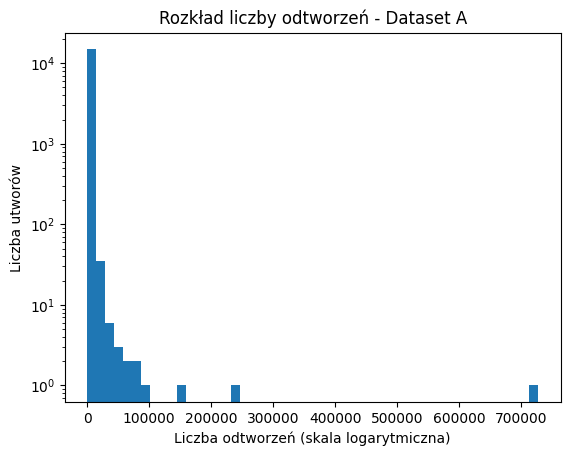

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df_A['play_count'].dropna(), bins=50, log=True)
plt.xlabel('Liczba odtworzeń (skala logarytmiczna)')
plt.ylabel('Liczba utworów')
plt.title('Rozkład liczby odtworzeń - Dataset A')
plt.show()

In [57]:
# print number of NA in each column
print(df_A.isna().sum())

segments_loudness_max           0
segments_pitches                0
segments_timbre                 0
duration                        0
end_of_fade_in                  0
key                             0
key_confidence                  0
loudness                        0
mode                            0
mode_confidence                 0
start_of_fade_out               0
tempo                           0
time_signature                  0
time_signature_confidence       0
artist_terms                    0
artist_terms_freq               0
artist_terms_weight             0
similar_artists                 0
artist_familiarity              1
artist_hotttnesss               0
artist_id                       0
artist_location              6694
artist_name                     0
release                         0
song_hotttnesss              2927
song_id                         0
title                           0
artist_mbtags                   0
year                            0
play_count    

In [ ]:
import numpy as np
import pandas as pd
import ast

GENRES_LIST = ['rock', 'pop', 'jazz', 'electronic', 'hip hop', 'rap', 'metal', 'soul', 'punk', 'classical']
REFERENCE_YEAR = 2011 

print(f"Rozmiar startowy: {df_A.shape}")

def parse_array_string(x):
    if isinstance(x, (list, np.ndarray)): return x
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('[') and x.endswith(']'):
            try:
                return ast.literal_eval(x)
            except:
                return []
    return []

array_cols = ['segments_loudness_max', 'segments_pitches', 'segments_timbre']
print("Konwertowanie napisów na listy...")
for col in array_cols:
    if col in df_A.columns:
        print(f"Przetwarzanie kolumny: {col}")
        df_A[col] = df_A[col].apply(parse_array_string)


def process_audio_arrays(row):
    stats = {}
    
    # 1. Dynamika (Loudness Max Std)
    try:
        loud_arr = np.array(row['segments_loudness_max'])
        stats['loudness_max_std'] = np.std(loud_arr) if len(loud_arr) > 0 else 0.0
    except:
        stats['loudness_max_std'] = 0.0

    # 2. Barwa (Timbre)
    try:
        timbre = np.array(row['segments_timbre'])
        if timbre.size > 0:
            stats['timbre_mean'] = np.mean(timbre)
            stats['timbre_std'] = np.std(timbre)
        else:
            stats['timbre_mean'] = 0.0
            stats['timbre_std'] = 0.0
    except:
        stats['timbre_mean'] = 0.0
        stats['timbre_std'] = 0.0

    # 3. Melodia (Pitches)
    try:
        pitches = np.array(row['segments_pitches'])
        stats['pitch_variety'] = np.sum(np.var(pitches, axis=0)) if pitches.size > 0 else 0.0
    except:
        stats['pitch_variety'] = 0.0
        
    return pd.Series(stats)

print("Wyliczanie statystyk audio...")
audio_features = df_A.apply(process_audio_arrays, axis=1)
df_A = pd.concat([df_A, audio_features], axis=1)


print("Przetwarzanie dat...")
df_A['year'] = pd.to_numeric(df_A['year'], errors='coerce').replace(0, np.nan)
df_A['year'] = df_A['year'].astype('Int64', errors='ignore')

df_A['song_age'] = REFERENCE_YEAR - df_A['year']
df_A['is_older_than_50s'] = (df_A['year'] < 1950).astype(int)
df_A['is_50s'] = ((df_A['year'] >= 1950) & (df_A['year'] < 1960)).astype(int)
df_A['is_60s'] = ((df_A['year'] >= 1960) & (df_A['year'] < 1970)).astype(int)
df_A['is_70s'] = ((df_A['year'] >= 1970) & (df_A['year'] < 1980)).astype(int)
df_A['is_80s'] = ((df_A['year'] >= 1980) & (df_A['year'] < 1990)).astype(int)
df_A['is_90s'] = ((df_A['year'] >= 1990) & (df_A['year'] < 2000)).astype(int)
df_A['is_00s'] = ((df_A['year'] >= 2000) & (df_A['year'] < 2011)).astype(int)


print("Target Encoding...")

# df_A['artist_avg_popularity'] = df_A.groupby('artist_id')['play_count'].transform('mean')
# df_A['album_avg_popularity'] = df_A.groupby('release')['play_count'].transform('mean')


print("Przetwarzanie gatunków...")
def combine_tags(row):
    terms = str(row['artist_terms']) if pd.notnull(row['artist_terms']) else ""
    mbtags = str(row['artist_mbtags']) if pd.notnull(row['artist_mbtags']) else ""
    return (terms + " " + mbtags).lower()

df_A['all_tags'] = df_A.apply(combine_tags, axis=1)

for genre in GENRES_LIST:
    col_name = f'is_{genre.replace(" ", "")}'
    df_A[col_name] = df_A['all_tags'].apply(lambda x: 1 if genre in x else 0)


cols_to_drop = [
    'segments_loudness_max', 'segments_pitches', 'segments_timbre', # Surowe tablice
    'artist_terms', 'artist_terms_freq', 'artist_terms_weight', 'artist_mbtags', 'all_tags', # Tekst
    'song_hotttnesss', # Data Leakage
    'artist_location', 'similar_artists' # Metadane
    
]

df_A = df_A.drop(columns=cols_to_drop, errors='ignore')
df_A = df_A.loc[:, ~df_A.columns.duplicated(keep='last')]

print("------------------------------------------------")
print("GOTOWE! Proces zakończony sukcesem.")
print(f"Rozmiar finalnego datasetu: {df_A.shape}")

Rozmiar startowy: (14896, 30)
Konwertowanie napisów na listy...
Przetwarzanie kolumny: segments_loudness_max
Przetwarzanie kolumny: segments_pitches
Przetwarzanie kolumny: segments_timbre
Wyliczanie statystyk audio...
Przetwarzanie dat...


ValueError: cannot convert NA to integer

In [ ]:
print("Przetwarzanie gatunków...")
def combine_tags(row):
    terms = str(row['artist_terms']) if pd.notnull(row['artist_terms']) else ""
    mbtags = str(row['artist_mbtags']) if pd.notnull(row['artist_mbtags']) else ""
    return (terms + " " + mbtags).lower()

df_A['all_tags'] = df_A.apply(combine_tags, axis=1)

for genre in GENRES_LIST:
    col_name = f'is_{genre.replace(" ", "")}'
    df_A[col_name] = df_A['all_tags'].apply(lambda x: 1 if genre in x else 0)


cols_to_drop = [
    'segments_loudness_max', 'segments_pitches', 'segments_timbre', # Surowe tablice
    'artist_terms', 'artist_terms_freq', 'artist_terms_weight', 'artist_mbtags', 'all_tags', # Tekst
    'song_hotttnesss', # Data Leakage
    'artist_location', 'similar_artists' # Metadane
]

df_A = df_A.drop(columns=cols_to_drop, errors='ignore')
#df_A = df_A.fillna(0)

df_A = df_A.loc[:, ~df_A.columns.duplicated(keep='last')]

print("------------------------------------------------")
print("GOTOWE! Proces zakończony sukcesem.")
print(f"Rozmiar finalnego datasetu: {df_A.shape}")

Przetwarzanie gatunków...
------------------------------------------------
GOTOWE! Proces zakończony sukcesem.
Rozmiar finalnego datasetu: (14896, 35)


In [10]:
cols_order = ['song_id', 'title', 'artist_name', 'release', 'year', 'play_count', 'duration', 'end_of_fade_in', 'key', 'key_confidence', 'loudness', 'mode', 'mode_confidence', 'start_of_fade_out', 'tempo', 'time_signature', 'time_signature_confidence', 'artist_familiarity', 'artist_hotttnesss', 'loudness_max_std', 'timbre_mean', 'timbre_std', 'pitch_variety', 'artist_avg_popularity', 'album_avg_popularity', 'is_rock', 'is_pop', 'is_jazz', 'is_electronic', 'is_hiphop', 'is_rap', 'is_metal', 'is_soul', 'is_punk', 'is_classical']
#len(cols_order)
# adjust final df column order
df_A = df_A[cols_order]


KeyboardInterrupt



In [12]:
df_A = df_A.drop(columns='song_age', errors='ignore')
df_A

,duration,end_of_fade_in,key,key_confidence,loudness,mode,mode_confidence,start_of_fade_out,tempo,time_signature,time_signature_confidence,artist_familiarity,artist_hotttnesss,artist_id,artist_name,release,song_id,title,year,play_count,loudness_max_std,timbre_mean,timbre_std,pitch_variety,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical
0,213.94240,0.000,1,0.349,-4.769,1,0.403,210.048,99.944,4,0.846,0.639903,0.461318,ARJNIUY12298900C91,Adelitas Way,Adelitas Way,SOBLFFE12AF72AA5BA,Scream,2009,515,3.568979,8.693521,29.778422,0.850126,1,0,0,0,0,0,1,0,0,0
1,118.07302,0.264,7,0.187,-7.240,1,0.425,115.142,125.475,4,0.546,0.671755,0.386606,AR73AIO1187B9AD57B,Western Addiction,Cognicide,SOQPWCR12A6D4FB2A3,A Poor Recipe For Civic Cohesion,2005,3,3.916606,4.481946,31.948210,0.837348,1,0,0,0,0,0,0,0,1,0
2,148.03546,0.148,6,0.169,-9.843,0,0.430,137.915,121.274,4,0.384,0.630630,0.417500,ARMJAGH1187FB546F3,The Box Tops,Dimensions,SOCIWDW12A8C13D406,Soul Deep,1969,72,5.957375,7.505631,27.285185,0.828015,1,1,0,0,0,0,0,1,0,0
3,252.94322,0.000,6,0.063,-7.227,0,0.400,247.455,161.990,4,0.253,0.013158,0.379282,AR9Q9YC1187FB5609B,Quest_ Pup_ Kevo,A Bad Azz Mix Tape IV,SOFRDWL12A58A7CEF7,Hit Da Scene,<NA>,2,5.028837,5.945927,41.650991,1.165935,1,1,1,1,1,1,1,1,0,0
4,129.85424,0.282,5,0.084,-9.495,1,0.301,121.452,156.677,4,0.000,0.422194,0.000000,ARSVTNL1187B992A91,Jonathan King,Vile Pervert - The Music,SOEKAZG12AB018837E,I'll Slap Your Face (Entertainment USA Theme),2001,2,4.261468,6.151135,31.617638,0.879958,1,1,1,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14891,39.47057,0.000,9,0.173,-13.686,1,0.358,39.471,111.195,5,0.877,0.834922,0.500215,ARANAED11F50C473A4,Lil Wyte,Doubt Me Now Dragged and Chopped,SOZTJBR12A8C142681,Death & Life (Skit),<NA>,60,6.254534,2.473721,38.831029,0.920113,1,1,0,0,1,1,1,0,1,0
14892,141.73995,0.427,7,0.616,-7.250,1,0.662,135.802,133.810,1,0.273,0.672448,0.504783,AR3WYZ21187B9B4F3F,Bikini Kill,Pussy Whipped,SOAKQBT12AB01803CB,Sugar,1993,203,3.456916,7.821654,28.397747,0.637518,1,1,0,1,0,0,0,0,1,0
14893,287.05914,0.177,0,0.703,-13.316,1,0.669,265.520,92.411,4,0.428,0.544749,0.417410,ARYJ6RP1187B9B3827,Cindy Morgan,A Reason To Live,SOOXNKG12A58A7C6BC,Someone Believes In You - Album Version,<NA>,24,8.724968,-2.242262,35.335854,1.023583,1,1,0,0,0,0,0,0,0,0
14894,172.98240,0.699,7,1.000,-10.238,1,0.977,165.407,176.087,4,0.602,0.559325,0.422439,AREFNKX1187B991576,Dan Zanes,House Party,SOCCODE12A8C136A89,We Shall Not Be Moved,<NA>,5,4.812911,4.848063,36.197606,0.915996,1,1,0,1,1,0,0,0,0,0


In [14]:
df_A.to_csv('../../DATA/processed/final_dataset_A.csv', index=False)

In [ ]:
del df_A

### Songs B-K

Aplikujemy tą samą logikę dla pozostałych datasetów

In [16]:
letters = ['B']#, 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K']
for letter in letters:
    print(f"Wczytywanie datasetu {letter}...")
    df = pd.read_csv(f'../../DATA/semi-processed/extracted_DataFrames/songs_{letter}.csv')
    df.columns = [col.split('/')[-1] for col in df.columns]
    df[play_counts.columns[1]] = df['song_id'].map(play_counts.set_index('song_id')['play_count'])
    globals()[f"df_{letter}"] = df
    
    print(f"Przetwarzanie datasetu {letter}...")
    for col in array_cols:
        if col in df.columns:
            print(f"Przetwarzanie kolumny: {col}")
            df[col] = df[col].apply(parse_array_string)

    print("Wyliczanie statystyk audio...")
    audio_features = df.apply(process_audio_arrays, axis=1)
    df = pd.concat([df, audio_features], axis=1)

    print("Przetwarzanie dat...")
    df['year'] = pd.to_numeric(df['year'], errors='coerce').replace(0, np.nan)
    # df['year'] = df['year'].astype('Int64', errors='ignore')

    # df['song_age'] = REFERENCE_YEAR - df['year']
    # df['is_older_than_50s'] = (df['year'] < 1950).astype(int)
    # df['is_50s'] = ((df['year'] >= 1950) & (df['year'] < 1960)).astype(int)
    # df['is_60s'] = ((df['year'] >= 1960) & (df['year'] < 1970)).astype(int)
    # df['is_70s'] = ((df['year'] >= 1970) & (df['year'] < 1980)).astype(int)
    # df['is_80s'] = ((df['year'] >= 1980) & (df['year'] < 1990)).astype(int)
    # df['is_90s'] = ((df['year'] >= 1990) & (df['year'] < 2000)).astype(int)
    # df['is_00s'] = ((df['year'] >= 2000) & (df['year'] < 2011)).astype(int)

    # print("Target Encoding...")
    # df['artist_avg_popularity'] = df.groupby('artist_id')['play_count'].transform('mean')
    # df['album_avg_popularity'] = df.groupby('release')['play_count'].transform('mean')

    df['all_tags'] = df.apply(combine_tags, axis=1)

    print("Przetwarzanie gatunków...")
    for genre in GENRES_LIST:
        col_name = f'is_{genre.replace(" ", "")}'
        df[col_name] = df['all_tags'].apply(lambda x: 1 if genre in x else 0)

    df = df.drop(columns=cols_to_drop, errors='ignore')
    df = df.loc[:, ~df.columns.duplicated(keep='last')]

    print(f"Gotowe! Rozmiar finalnego datasetu {letter}:", df.shape)
    df.to_csv(f'../../DATA/processed/final_dataset_{letter}.csv', index=False)
    # w celu zwolnienia pamięci - nie da się wczytać wszystkich naraz
    del globals()[f"df_{letter}"]

Wczytywanie datasetu B...
Przetwarzanie datasetu B...
Przetwarzanie kolumny: segments_loudness_max
Przetwarzanie kolumny: segments_pitches
Przetwarzanie kolumny: segments_timbre
Wyliczanie statystyk audio...
Przetwarzanie dat...
Przetwarzanie gatunków...
Gotowe! Rozmiar finalnego datasetu B: (14542, 34)


In [17]:
letters = ['C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K']
for letter in letters:
    print(f"Wczytywanie datasetu {letter}...")
    df = pd.read_csv(f'../../DATA/semi-processed/extracted_DataFrames/songs_{letter}.csv')
    df.columns = [col.split('/')[-1] for col in df.columns]
    df[play_counts.columns[1]] = df['song_id'].map(play_counts.set_index('song_id')['play_count'])
    globals()[f"df_{letter}"] = df
    
    print(f"Przetwarzanie datasetu {letter}...")
    for col in array_cols:
        if col in df.columns:
            print(f"Przetwarzanie kolumny: {col}")
            df[col] = df[col].apply(parse_array_string)

    print("Wyliczanie statystyk audio...")
    audio_features = df.apply(process_audio_arrays, axis=1)
    df = pd.concat([df, audio_features], axis=1)

    print("Przetwarzanie dat...")
    df['year'] = pd.to_numeric(df['year'], errors='coerce').replace(0, np.nan)
    # df['year'] = df['year'].astype('Int64', errors='ignore')

    # df['song_age'] = REFERENCE_YEAR - df['year']
    # df['is_older_than_50s'] = (df['year'] < 1950).astype(int)
    # df['is_50s'] = ((df['year'] >= 1950) & (df['year'] < 1960)).astype(int)
    # df['is_60s'] = ((df['year'] >= 1960) & (df['year'] < 1970)).astype(int)
    # df['is_70s'] = ((df['year'] >= 1970) & (df['year'] < 1980)).astype(int)
    # df['is_80s'] = ((df['year'] >= 1980) & (df['year'] < 1990)).astype(int)
    # df['is_90s'] = ((df['year'] >= 1990) & (df['year'] < 2000)).astype(int)
    # df['is_00s'] = ((df['year'] >= 2000) & (df['year'] < 2011)).astype(int)

    # print("Target Encoding...")
    # df['artist_avg_popularity'] = df.groupby('artist_id')['play_count'].transform('mean')
    # df['album_avg_popularity'] = df.groupby('release')['play_count'].transform('mean')

    df['all_tags'] = df.apply(combine_tags, axis=1)

    print("Przetwarzanie gatunków...")
    for genre in GENRES_LIST:
        col_name = f'is_{genre.replace(" ", "")}'
        df[col_name] = df['all_tags'].apply(lambda x: 1 if genre in x else 0)

    df = df.drop(columns=cols_to_drop, errors='ignore')
    df = df.loc[:, ~df.columns.duplicated(keep='last')]

    print(f"Gotowe! Rozmiar finalnego datasetu {letter}:", df.shape)
    df.to_csv(f'../../DATA/processed/final_dataset_{letter}.csv', index=False)
    # w celu zwolnienia pamięci - nie da się wczytać wszystkich naraz
    del globals()[f"df_{letter}"]

Wczytywanie datasetu C...
Przetwarzanie datasetu C...
Przetwarzanie kolumny: segments_loudness_max
Przetwarzanie kolumny: segments_pitches
Przetwarzanie kolumny: segments_timbre
Wyliczanie statystyk audio...
Przetwarzanie dat...
Przetwarzanie gatunków...
Gotowe! Rozmiar finalnego datasetu C: (14637, 34)
Wczytywanie datasetu D...
Przetwarzanie datasetu D...
Przetwarzanie kolumny: segments_loudness_max
Przetwarzanie kolumny: segments_pitches
Przetwarzanie kolumny: segments_timbre
Wyliczanie statystyk audio...
Przetwarzanie dat...
Przetwarzanie gatunków...
Gotowe! Rozmiar finalnego datasetu D: (14901, 34)
Wczytywanie datasetu E...
Przetwarzanie datasetu E...
Przetwarzanie kolumny: segments_loudness_max
Przetwarzanie kolumny: segments_pitches
Przetwarzanie kolumny: segments_timbre
Wyliczanie statystyk audio...
Przetwarzanie dat...
Przetwarzanie gatunków...
Gotowe! Rozmiar finalnego datasetu E: (14637, 34)
Wczytywanie datasetu F...
Przetwarzanie datasetu F...
Przetwarzanie kolumny: segments

#### Rozkład zmiennej objaśnianej w poszczególnych datasetach

Wczytanie finalnych datasetów

In [18]:
letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K']
for letter in letters:
    globals()[f"df_{letter}"] = pd.read_csv(f'../../DATA/processed/final_dfs/final_dataset_{letter}.csv')

Porównanie rozkładów w poszczególnych datasetach

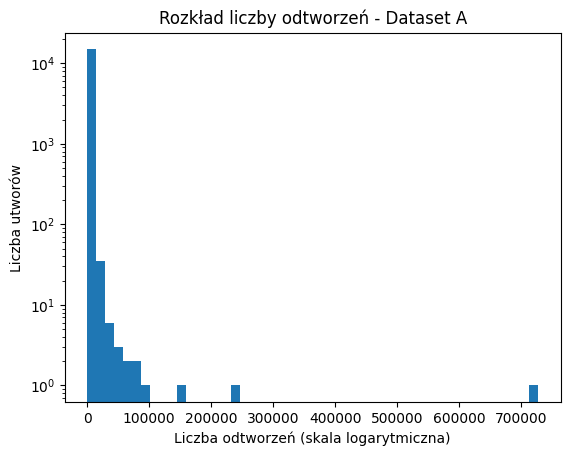

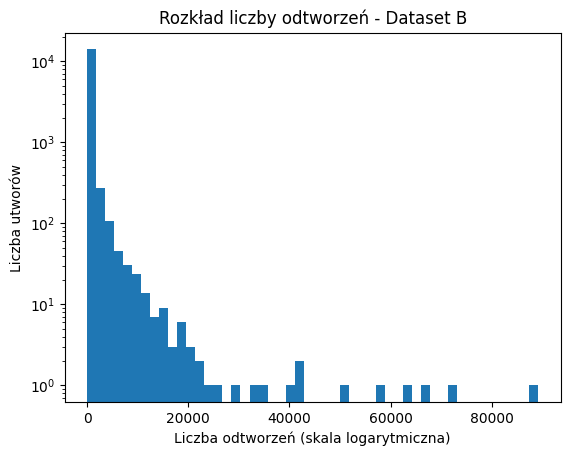

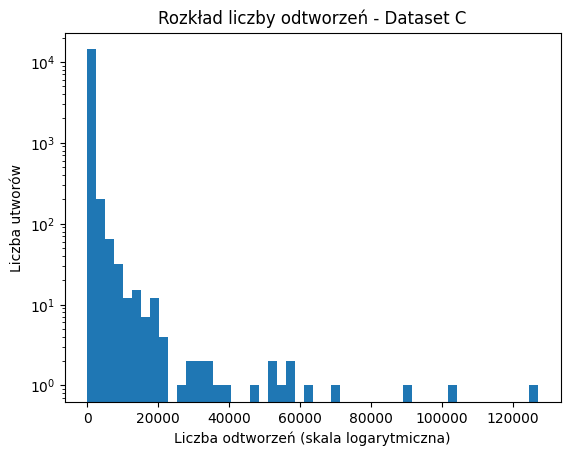

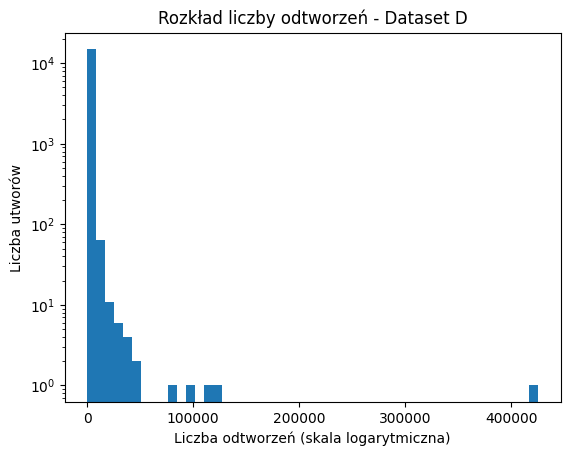

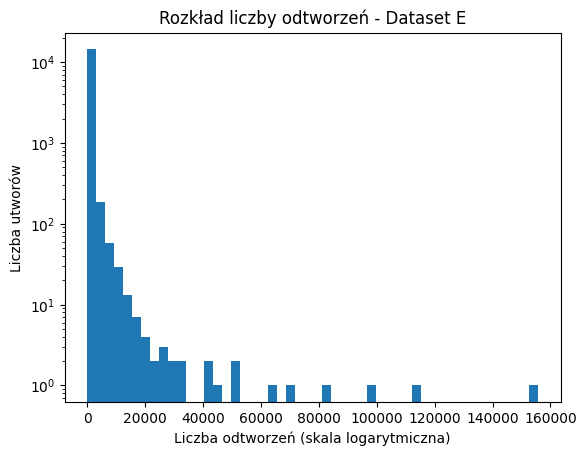

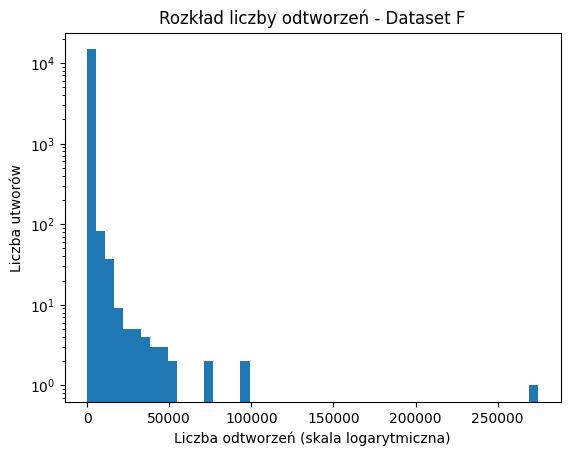

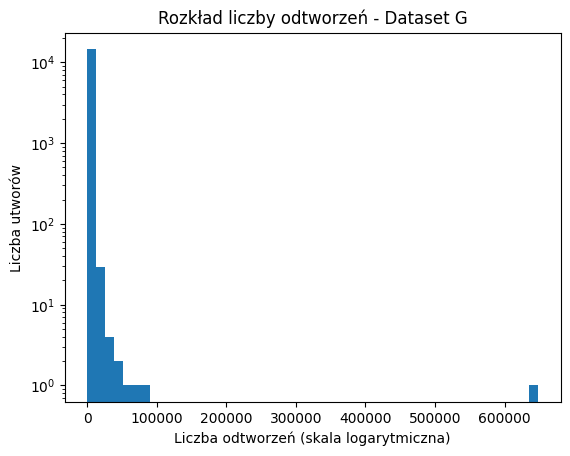

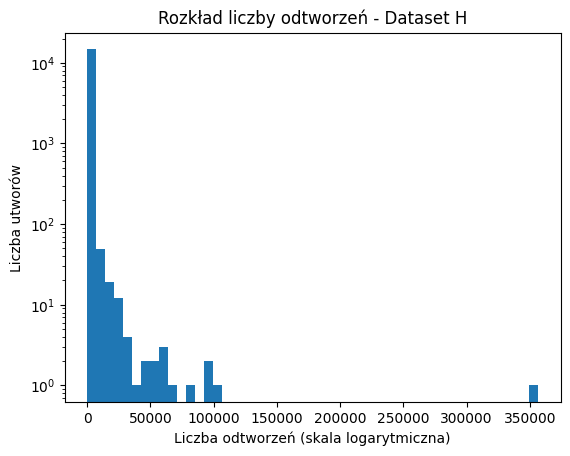

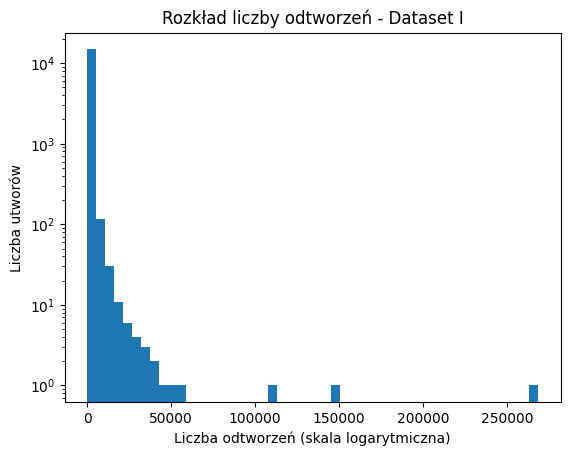

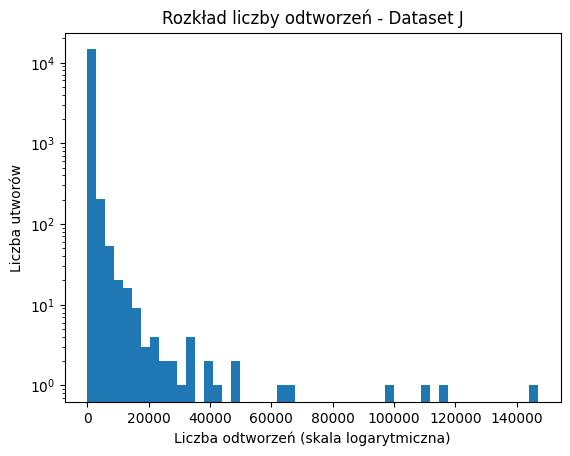

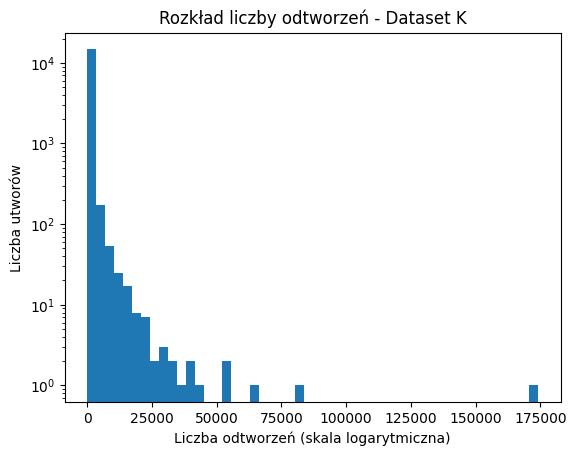

In [21]:
import matplotlib.pyplot as plt
dfs = [df_A, df_B, df_C, df_D, df_E, df_F, df_G, df_H, df_I, df_J, df_K]
for i, df in enumerate(dfs):
    plt.hist(df['play_count'].dropna(), bins=50, log=True)
    plt.xlabel('Liczba odtworzeń (skala logarytmiczna)')
    plt.ylabel('Liczba utworów')
    plt.title(f'Rozkład liczby odtworzeń - Dataset {chr(65+i)}')
    plt.show()

Sprawdzenie wartości NaN - głównie kolumna 'year' do dalszego preprocessingu

In [22]:
for i, df in enumerate(dfs):
    # change year 0 to NaN for better NA counting
    df['year'] = df['year'].replace(0, np.nan)
    print(f"Dataset {chr(65+i)} - NA counts:")
    print(df.isna().sum())

Dataset A - NA counts:
duration                        0
end_of_fade_in                  0
key                             0
key_confidence                  0
loudness                        0
mode                            0
mode_confidence                 0
start_of_fade_out               0
tempo                           0
time_signature                  0
time_signature_confidence       0
artist_familiarity              1
artist_hotttnesss               0
artist_id                       0
artist_name                     0
release                         0
song_id                         0
title                           0
year                         4762
play_count                      0
loudness_max_std                0
timbre_mean                     0
timbre_std                      0
pitch_variety                   0
is_rock                         0
is_pop                          0
is_jazz                         0
is_electronic                   0
is_hiphop                

Zapisanie pełnego, wstępnie przetworzonego datasetu

In [23]:
all_songs = pd.concat(dfs, ignore_index=True)
all_songs.to_csv('../../DATA/all_songs_with_play_counts.csv', index=False)

In [24]:
all_songs.shape

(162469, 34)